# MIMIC-IV-Ext-ECG-Glucose v1.0.0: exemplar usage notebook

**Supplementary Code S2**

> **Dataset:** `mimiciv_ecg_glucose_aligned.csv` (PhysioNet, credentialed access)
> **Code:** this repository; shared, leak-free helpers live in the `glucoecg` package

This notebook shows the recommended workflow:

1. Load the CSV with the shared cleaning and causal-history features
2. Inspect splits, usability tiers, SQI and intervention annotations
3. See which columns must **not** be model inputs, and why
4. Train a leak-free XGBoost baseline on the recommended subset
5. Evaluate with patient-level bootstrap CIs and the corrected Clarke and Parkes error grids

CPU only, about 4 GB RAM.

## 1. Environment

In [2]:
import os, sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the repository's glucoecg package importable from notebooks/
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))

from glucoecg import config
from glucoecg.features import (load_dataset, test_sets, FEATURE_SETS, FEATURE_SET_LABELS,
                               FORBIDDEN_INPUTS, TARGET_DERIVED, RETROSPECTIVE, INTERVENTION, TARGET)
from glucoecg.metrics import (regression_metrics, bootstrap_ci, clarke_zones, parkes_zones,
                              zone_summary, GLYCAEMIC_BANDS)
from glucoecg.modeling import train_feature_set

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110})
print('Ready')

Ready


## 2. Load the dataset

`load_dataset` reads the CSV, converts booleans, treats ECG "not measured" codes (29999, 32767, 65535) and RR = 0 as missing,
and adds history features built only from **strictly earlier** glucose records of the same patient (`prior_*`, `lag_ok`).

In [3]:
CSV_PATH = os.environ.get('GLUCOECG_CSV', 'mimiciv_ecg_glucose_aligned.csv')
digest = config.check_csv(Path(CSV_PATH))     # warns if the file is not PhysioNet v1.0.0
df = load_dataset(CSV_PATH)
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns | {df['subject_id'].nunique():,} patients")

  Loaded 437,671 records | 131,771 patients
437,671 rows x 117 columns | 131,771 patients


## 3. Split and usability tiers

In [4]:
# Split × Usability tier cross-tabulation
split_order = ['TRAIN', 'VALIDATION', 'TEST']
tier_order  = ['IDEAL', 'USABLE', 'CAUTION', 'EXCLUDE']

cross = pd.crosstab(
    df['split'], df['record_usability'],
    margins=True, margins_name='TOTAL'
).reindex(split_order + ['TOTAL'])

print("Records by Split × Usability Tier")
print("=" * 60)
print(cross.to_string())

print()
# Usability tier definitions
print("\nUsability tier definitions (SQL CASE order):")
print("  EXCLUDE — dual insulin + dextrose, POOR SQI, or bradycardia QTc divergence > 200 ms")
print("  CAUTION — FLAG_HIGH_RISK, FAIR SQI, confounded delta, or gap < 15 min / > 6 h")
print("  IDEAL   — ECG before glucose, TIGHT/MODERATE, CLEAN, GOOD SQI, valid previous value")
print("  USABLE  — all other records (e.g. first draw in stay, LOOSE/EXTENDED, ECG after glucose)")

Records by Split × Usability Tier
record_usability  CAUTION  EXCLUDE  IDEAL  USABLE   TOTAL
split                                                    
TRAIN              236235    17735   3418   92588  349976
VALIDATION          30186     2213    468   11851   44718
TEST                28613     2219    478   11667   42977
TOTAL              295034    22167   4364  116106  437671


Usability tier definitions (SQL CASE order):
  EXCLUDE — dual insulin + dextrose, POOR SQI, or bradycardia QTc divergence > 200 ms
  CAUTION — FLAG_HIGH_RISK, FAIR SQI, confounded delta, or gap < 15 min / > 6 h
  IDEAL   — ECG before glucose, TIGHT/MODERATE, CLEAN, GOOD SQI, valid previous value
  USABLE  — all other records (e.g. first draw in stay, LOOSE/EXTENDED, ECG after glucose)


## 4. Columns that must not be model inputs

The file keeps some columns for description and stratification that are computed from the target glucose
(e.g. `patient_mean_glucose` averages **all** of a patient's records, including the current one; `glucose_delta_mg_dl`
is the current glucose minus the previous one), columns known only after discharge, and intervention flags whose
symmetric windows include insulin given **after** the blood draw. Using any of them as a predictor leaks the answer.
`glucoecg.features.assert_no_leak` refuses them.

In [5]:
for name, cols in [('Target-derived', TARGET_DERIVED), ('Known only after the measurement', RETROSPECTIVE),
                   ('Intervention annotations (filter / stratify only)', INTERVENTION)]:
    print(f"{name}:\n  " + ", ".join(sorted(cols)) + "\n")

for k, cols in FEATURE_SETS.items():
    print(f"{FEATURE_SET_LABELS[k]}: {len(cols)} inputs")

# Leak check example: a single-record patient's patient_mean_glucose IS the target
single = df['n_glucose_ecg_pairs'] == 1
print(f"\nRows from single-record patients: {single.sum():,}; "
      f"patient_mean_glucose == glucose_mg_dl in {np.isclose(df.loc[single, 'patient_mean_glucose'], df.loc[single, TARGET]).mean():.0%} of them")

Target-derived:
  glucose_cv_percent, glucose_delta_mg_dl, glucose_mg_dl, glucose_minmax_norm, glucose_rate_mg_dl_per_hr, glucose_trajectory, glucose_z_score, glycemic_class, lab_flag, patient_max_glucose, patient_mean_glucose, patient_min_glucose, patient_std_glucose, time_above_range_pct, time_below_range_pct, time_in_range_pct

Known only after the measurement:
  hospital_expire_flag, icu_los_days, last_careunit, n_glucose_ecg_pairs

Intervention annotations (filter / stratify only):
  decoupling_risk_score, delta_is_intervention_confounded, dextrose_active, dual_intervention_active, fast_insulin_active, insulin_active, intervention_status, lag_intervention_status, max_dextrose_amount_ml, max_insulin_dose_units

XGBoost, ECG only: 23 inputs
XGBoost, causal history + context: 21 inputs
XGBoost, ECG + causal history + context: 44 inputs

Rows from single-record patients: 61,258; patient_mean_glucose == glucose_mg_dl in 100% of them


## 5. ECG signal quality index (SQI)

SQI = max(0, sum of 10 binary checks - 3 x report_artifact_flag), range 0-10; GOOD >= 8, FAIR 5-7, POOR <= 4.
The P-wave checks fail when no P wave is measured (e.g. atrial fibrillation), so FAIR partly reflects rhythm.

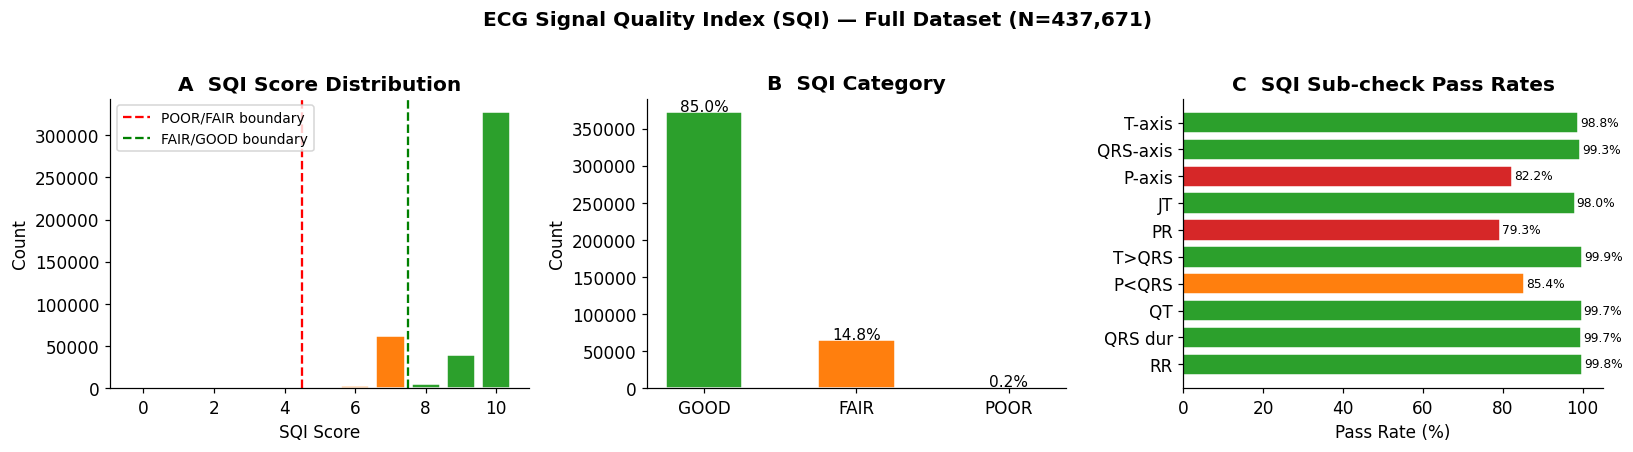

Figure saved: sqi_exploration.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel A: SQI score distribution
all_data = df
sqi_counts = all_data['sqi_score'].value_counts().sort_index()
colors = ['#d62728' if s <= 4 else '#ff7f0e' if s <= 7 else '#2ca02c'
          for s in sqi_counts.index]
axes[0].bar(sqi_counts.index, sqi_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('SQI Score')
axes[0].set_ylabel('Count')
axes[0].set_title('A  SQI Score Distribution', fontweight='bold')
axes[0].axvline(4.5, color='red', lw=1.5, ls='--', label='POOR/FAIR boundary')
axes[0].axvline(7.5, color='green', lw=1.5, ls='--', label='FAIR/GOOD boundary')
axes[0].legend(fontsize=9)

# Panel B: SQI category
cat_counts = all_data['sqi_category'].value_counts()
cat_colors = {'GOOD': '#2ca02c', 'FAIR': '#ff7f0e', 'POOR': '#d62728'}
cat_order  = ['GOOD', 'FAIR', 'POOR']
axes[1].bar(cat_order,
            [cat_counts.get(c, 0) for c in cat_order],
            color=[cat_colors[c] for c in cat_order],
            edgecolor='white', width=0.5)
axes[1].set_ylabel('Count')
axes[1].set_title('B  SQI Category', fontweight='bold')
for i, cat in enumerate(cat_order):
    n = cat_counts.get(cat, 0)
    axes[1].text(i, n + 1000, f'{n/len(all_data)*100:.1f}%', ha='center', fontsize=10)

# Panel C: Sub-check pass rates
sub_checks = ['sqi_rr_ok','sqi_qrs_ok','sqi_qt_ok','sqi_p_before_qrs',
              'sqi_t_after_qrs','sqi_pr_ok','sqi_jt_ok',
              'sqi_p_axis_ok','sqi_qrs_axis_ok','sqi_t_axis_ok']
labels = ['RR','QRS dur','QT','P<QRS','T>QRS','PR','JT','P-axis','QRS-axis','T-axis']
pass_rates = []
for col in sub_checks:
    if col in all_data.columns:
        pr = all_data[col].astype(float).mean() * 100
    else:
        pr = 0
    pass_rates.append(pr)

bar_colors = ['#d62728' if p < 85 else '#ff7f0e' if p < 95 else '#2ca02c'
              for p in pass_rates]
axes[2].barh(labels, pass_rates, color=bar_colors, edgecolor='white')
axes[2].set_xlabel('Pass Rate (%)')
axes[2].set_title('C  SQI Sub-check Pass Rates', fontweight='bold')
axes[2].set_xlim(0, 105)
for i, p in enumerate(pass_rates):
    axes[2].text(p + 0.5, i, f'{p:.1f}%', va='center', fontsize=8)

plt.suptitle('ECG Signal Quality Index (SQI) — Full Dataset (N=437,671)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sqi_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: sqi_exploration.png")


## 6. Pharmacological intervention annotations

Derived from ICU `inputevents` only: for the 81.6% of records outside an ICU stay, `CLEAN` means *not annotated*.
`decoupling_risk_score` = 2 x fast-acting insulin + 1 x dextrose + 1 x dual; observed values 0, 1, 2, 4.

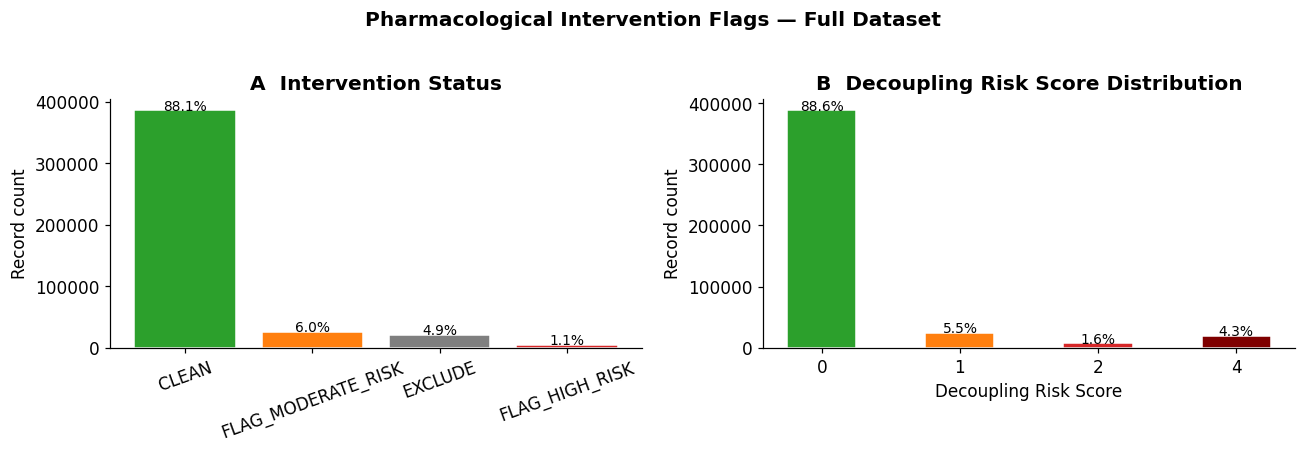


Intervention status breakdown:
  CLEAN                 : 385,544 (88.1%)
  FLAG_MODERATE_RISK    :  26,112 (6.0%)
  EXCLUDE               :  21,290 (4.9%)
  FLAG_HIGH_RISK        :   4,725 (1.1%)

Score values: 0, 1, 2, 4 (3 cannot occur). Score 2 = fast-acting insulin alone OR basal insulin + dextrose.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: Intervention status
intv_counts = df['intervention_status'].value_counts()
intv_colors = {
    'CLEAN':             '#2ca02c',
    'FLAG_MODERATE_RISK':'#ff7f0e',
    'FLAG_HIGH_RISK':    '#d62728',
    'EXCLUDE':           '#7f7f7f',
}
bars = axes[0].bar(intv_counts.index, intv_counts.values,
                   color=[intv_colors.get(x, '#1f77b4') for x in intv_counts.index],
                   edgecolor='white')
axes[0].set_ylabel('Record count')
axes[0].set_title('A  Intervention Status', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)
for bar, (label, count) in zip(bars, intv_counts.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count/len(df)*100:.1f}%', ha='center', fontsize=9)

# Panel B: Risk score distribution
risk_counts = df['decoupling_risk_score'].value_counts().sort_index()
risk_colors = {0: '#2ca02c', 1: '#ff7f0e', 2: '#d62728',
               3: '#9467bd', 4: '#7f0000'}
axes[1].bar(risk_counts.index.astype(str), risk_counts.values,
            color=[risk_colors.get(int(i), '#1f77b4') for i in risk_counts.index],
            edgecolor='white', width=0.5)
axes[1].set_xlabel('Decoupling Risk Score')
axes[1].set_ylabel('Record count')
axes[1].set_title('B  Decoupling Risk Score Distribution', fontweight='bold')
for i, (score, count) in enumerate(risk_counts.items()):
    axes[1].text(i, count + 500, f'{count/len(df)*100:.1f}%', ha='center', fontsize=9)

plt.suptitle('Pharmacological Intervention Flags — Full Dataset', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('intervention_flags.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nIntervention status breakdown:")
for status, count in intv_counts.items():
    print(f"  {status:<22}: {count:>7,} ({count/len(df)*100:.1f}%)")
print("\nScore values: 0, 1, 2, 4 (3 cannot occur). Score 2 = fast-acting insulin alone OR basal insulin + dextrose.")


## 7. Glucose distribution and class imbalance

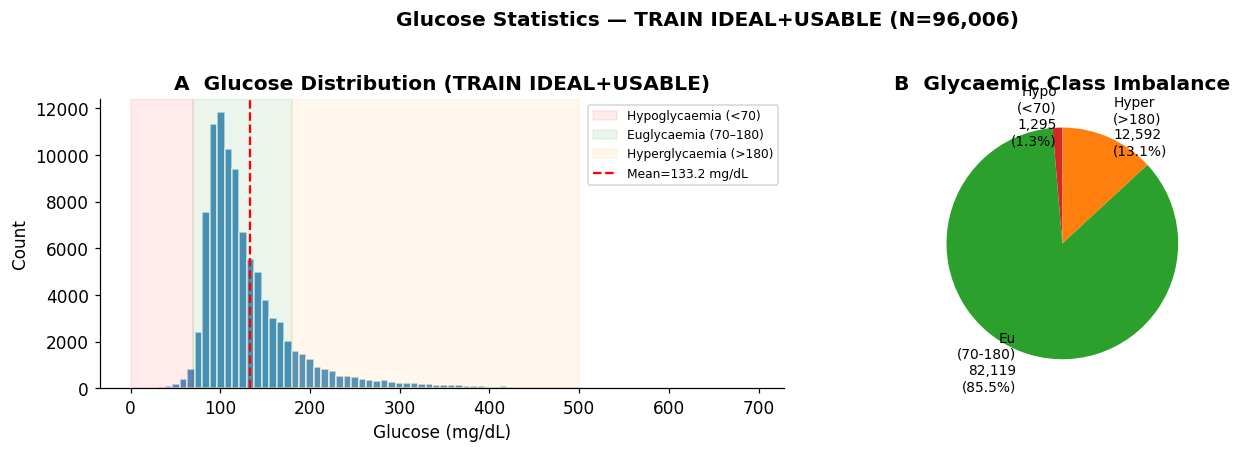

Glucose statistics (TRAIN IDEAL+USABLE):
  Mean  : 133.16 mg/dL
  Std   : 61.81 mg/dL
  Median: 115.0 mg/dL
  Range : [30, 694] mg/dL

Class imbalance (dominant reason for regression-to-mean bias):
  Hypoglycaemia:  1,295 (1.3%)
  Euglycaemia  : 82,119 (85.5%)
  Hyperglycaemia:12,592 (13.1%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel A: Glucose histogram with clinical zones
train_ideal_usable = df[
    (df['split'] == 'TRAIN') &
    (df['record_usability'].isin(['IDEAL', 'USABLE']))
]
glucose = train_ideal_usable['glucose_mg_dl'].dropna()

axes[0].hist(glucose, bins=80, color='#1f77b4', alpha=0.8, edgecolor='white')
axes[0].axvspan(0,   70,  alpha=0.08, color='red',    label='Hypoglycaemia (<70)')
axes[0].axvspan(70,  180, alpha=0.08, color='green',  label='Euglycaemia (70–180)')
axes[0].axvspan(180, 500, alpha=0.08, color='orange', label='Hyperglycaemia (>180)')
axes[0].axvline(glucose.mean(), color='red', lw=1.5, ls='--',
                label=f'Mean={glucose.mean():.1f} mg/dL')
axes[0].set_xlabel('Glucose (mg/dL)')
axes[0].set_ylabel('Count')
axes[0].set_title('A  Glucose Distribution (TRAIN IDEAL+USABLE)', fontweight='bold')
axes[0].legend(fontsize=8)

# Panel B: Class imbalance pie
hypo  = (glucose < 70).sum()
eu    = ((glucose >= 70) & (glucose <= 180)).sum()
hyper = (glucose > 180).sum()
sizes  = [hypo, eu, hyper]
labels = [f'Hypo\n(<70)\n{hypo:,}\n({hypo/len(glucose)*100:.1f}%)',
          f'Eu\n(70-180)\n{eu:,}\n({eu/len(glucose)*100:.1f}%)',
          f'Hyper\n(>180)\n{hyper:,}\n({hyper/len(glucose)*100:.1f}%)']
colors = ['#d62728', '#2ca02c', '#ff7f0e']
wedges, texts = axes[1].pie(sizes, labels=labels, colors=colors,
                             startangle=90, textprops={'fontsize': 9})
axes[1].set_title('B  Glycaemic Class Imbalance', fontweight='bold')

plt.suptitle(f'Glucose Statistics — TRAIN IDEAL+USABLE (N={len(glucose):,})',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('glucose_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Glucose statistics (TRAIN IDEAL+USABLE):")
print(f"  Mean  : {glucose.mean():.2f} mg/dL")
print(f"  Std   : {glucose.std():.2f} mg/dL")
print(f"  Median: {glucose.median():.1f} mg/dL")
print(f"  Range : [{glucose.min():.0f}, {glucose.max():.0f}] mg/dL")
print(f"\nClass imbalance (dominant reason for regression-to-mean bias):")
print(f"  Hypoglycaemia: {hypo:>6,} ({hypo/len(glucose)*100:.1f}%)")
print(f"  Euglycaemia  : {eu:>6,} ({eu/len(glucose)*100:.1f}%)")
print(f"  Hyperglycaemia:{hyper:>6,} ({hyper/len(glucose)*100:.1f}%)")


## 8. Recommended subset

The PhysioNet README's conservative filter: `record_usability IN ('IDEAL','USABLE')`,
`temporal_relationship = 'ECG_BEFORE_GLUCOSE'`, `intervention_status = 'CLEAN'`. Always use the provided `split` column
(assigned per patient).

In [9]:
tests = test_sets(df)
cons = (df['record_usability'].isin(['IDEAL', 'USABLE']) & (df['temporal_relationship'] == 'ECG_BEFORE_GLUCOSE')
        & (df['intervention_status'] == 'CLEAN'))
print(pd.crosstab(df.loc[cons, 'split'], df.loc[cons, 'record_usability'], margins=True))
print(f"\nTEST rows with any earlier record of the same patient: "
      f"{tests['iu_history'].sum():,} of {tests['iu'].sum():,} IDEAL+USABLE")

record_usability  IDEAL  USABLE    All
split                                 
TEST                478    5675   6153
TRAIN              3418   45093  48511
VALIDATION          468    5691   6159
All                4364   56459  60823

TEST rows with any earlier record of the same patient: 4,592 of 12,145 IDEAL+USABLE


## 9. Leak-free XGBoost baseline

Same hyperparameters as the paper; trained on IDEAL+USABLE TRAIN rows, early-stopped on VALIDATION, scored on TEST
with a patient-level bootstrap CI (200 resamples here; 1,000 in `validation/baseline_xgboost.py`).

In [10]:
y = df[TARGET].to_numpy(float)
ids = df['subject_id'].to_numpy()
preds = {}
for fs in ['ecg_only', 'ecg_history']:
    model, preds[fs] = train_feature_set(df, fs, 'iu', seed=42)
    for key in ['iu', 'conservative', 'iu_no_history']:
        m = tests[key]
        r = regression_metrics(y[m], preds[fs][m])
        lo, hi = bootstrap_ci(y[m], preds[fs][m], ids[m], n_boot=200)
        print(f"{FEATURE_SET_LABELS[fs]:42s} {key:14s} n={r['n']:6,d}  MAE {r['mae']:.2f} [{lo:.2f}, {hi:.2f}]  R2 {r['r2']:.3f}")

lag = df['lag_ok'].to_numpy(float)
m = tests['iu'] & ~np.isnan(lag)
print(f"\nLast-value baseline (previous draw >= 15 min earlier): n={m.sum():,}  "
      f"MAE {regression_metrics(y[m], lag[m])['mae']:.2f}")

XGBoost, ECG only                          iu             n=12,145  MAE 38.31 [37.36, 39.52]  R2 0.056
XGBoost, ECG only                          conservative   n= 6,153  MAE 38.86 [37.55, 40.18]  R2 0.060
XGBoost, ECG only                          iu_no_history  n= 7,553  MAE 36.17 [35.26, 37.00]  R2 0.054
XGBoost, ECG + causal history + context    iu             n=12,145  MAE 30.16 [29.47, 31.01]  R2 0.337
XGBoost, ECG + causal history + context    conservative   n= 6,153  MAE 30.00 [28.79, 30.89]  R2 0.381
XGBoost, ECG + causal history + context    iu_no_history  n= 7,553  MAE 32.66 [31.73, 33.58]  R2 0.100

Last-value baseline (previous draw >= 15 min earlier): n=3,597  MAE 28.75


## 10. Clarke and Parkes error grids

`clarke_zones` follows Clarke et al. (1987): a true hypoglycaemia predicted at 70-180 mg/dL is Zone D
("failure to detect"). `parkes_zones` uses the type 1 consensus grid of Parkes et al. (2000).

   Clarke %  Parkes %
A     56.36     62.03
B     38.85     33.14
C      0.21      4.41
D      4.55      0.42
E      0.02      0.01


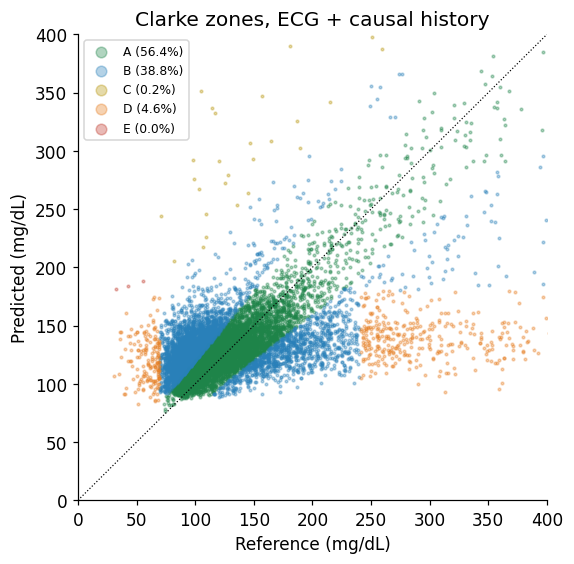

In [11]:
m = tests['iu']
p = preds['ecg_history']
cz, pz = zone_summary(clarke_zones(y[m], p[m])), zone_summary(parkes_zones(y[m], p[m]))
print(pd.DataFrame({'Clarke %': {k: cz[k] for k in 'ABCDE'}, 'Parkes %': {k: pz[k] for k in 'ABCDE'}}).round(2))

zones = clarke_zones(y[m], p[m])
colors = dict(A='#1E8449', B='#2980B9', C='#B7950B', D='#E67E22', E='#C0392B')
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for z in 'ABCDE':
    s = zones == z
    ax.scatter(y[m][s], p[m][s], s=3, alpha=0.35, color=colors[z], label=f'{z} ({s.mean()*100:.1f}%)')
ax.plot([0, 400], [0, 400], 'k:', lw=0.8)
ax.set(xlim=(0, 400), ylim=(0, 400), xlabel='Reference (mg/dL)', ylabel='Predicted (mg/dL)',
       title='Clarke zones, ECG + causal history')
ax.legend(markerscale=4, fontsize=8)
plt.show()

## 11. Performance by glycaemic band

In [12]:
rows = {k: regression_metrics(y[m][f(y[m])], p[m][f(y[m])]) for k, f in GLYCAEMIC_BANDS.items()}
print(pd.DataFrame(rows).T[['n', 'mae', 'bias']].round(2))
print('\nRegression to the mean: hypoglycaemia is over-predicted and hyperglycaemia under-predicted.')

                    n    mae   bias
hypo (<70)      171.0  62.70  62.70
eu (70-180)   10408.0  21.00  11.22
hyper (>180)   1566.0  87.49 -81.04

Regression to the mean: hypoglycaemia is over-predicted and hyperglycaemia under-predicted.


## Notes

* History features use only earlier records **in this file** (glucose values with an ECG within +/-240 min) plus the
  all-labs `lag_glucose_mg_dl`. With MIMIC-IV access you can extend them from `labevents` through `labevent_id`.
* ECG timestamps come from the cart clock, which was not synchronised with hospital systems
  (see the MIMIC-IV-ECG documentation), so alignment tiers are nominal.
* The full benchmark with all models, seeds and figures is `validation/baseline_xgboost.py`.